In [1]:
# Step 1: Install & Imports
!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn torch

import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Create a dummy CSV file for demonstration purposes
dummy_data = {
    'title': [
        'Breaking: Scientists discover water on Mars',
        'Exclusive: Local resident spots Bigfoot in national park',
        'New study shows health benefits of daily chocolate consumption',
        'Government announces new policy on renewable energy',
        'Tabloid claims celebrity is an alien robot',
        'Expert analysis on global economic trends',
        'New research confirms benefits of meditation for stress',
        'Another politician involved in scandal uncovered',
        'Global warming effects becoming more evident every year',
        'Fake news article about celebrity cloning goes viral',
        'Major breakthrough in cancer research announced',
        'Conspiracy theory about moon landing debunked',
        'Study reveals dangers of excessive screen time',
        'Sensational headline about a new animal species discovered'
    ],
    'text': [
        'Recent findings from NASA rovers confirm the presence of liquid water.',
        'Eyewitness accounts describe a large, hairy bipedal creature.',
        'Researchers from a leading university published their findings today.',
        'The environment minister detailed the initiative in a press conference.',
        'Sources close to the star reveal shocking information.',
        'Economists weigh in on the potential impact of recent market shifts.',
        'Scientists confirm that daily meditation can significantly reduce stress levels.',
        'Reports suggest a prominent politician has been linked to a major financial impropriety.',
        'Climate models show an accelerating trend in global temperature rise.',
        'Unverified reports claim a famous actor has been replaced by a clone.',
        'A novel treatment showing high efficacy in late-stage trials was revealed.',
        'Experts provide overwhelming evidence disproving lunar landing conspiracy theories.',
        'Medical study highlights the negative health impacts of prolonged digital device use.',
        'A bizarre new creature was reportedly found in the Amazon rainforest.'
    ],
    'fake_or_factual': [
        'Factual News', 'Fake News', 'Factual News',
        'Factual News', 'Fake News', 'Factual News',
        'Factual News', 'Fake News', 'Factual News',
        'Fake News', 'Factual News', 'Fake News',
        'Factual News', 'Fake News'
    ]
}
dummy_df = pd.DataFrame(dummy_data)
dummy_df.to_csv('fake_news_data.csv', index=False)

# Step 2: Load Data
df = pd.read_csv('fake_news_data.csv')
df['label'] = df['fake_or_factual'].map({'Factual News': 0, 'Fake News': 1})
df['content'] = df['title'].astype(str) + " [SEP] " + df['text'].astype(str)

# Step 3: Split Data
X_train, X_temp, y_train, y_temp = train_test_split(df['content'].tolist(), df['label'].tolist(), test_size=0.3, stratify=df['label'], random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

# Step 4: Tokenization & Dataset
MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=256)
val_enc = tokenizer(X_val, truncation=True, padding=True, max_length=256)

train_dataset = NewsDataset(train_enc, y_train)
val_dataset = NewsDataset(val_enc, y_val)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Step 5: Model Setup
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Step 6: Training Loop
for epoch in range(3):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.


Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

Factual News       1.00      1.00      1.00         2
   Fake News       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



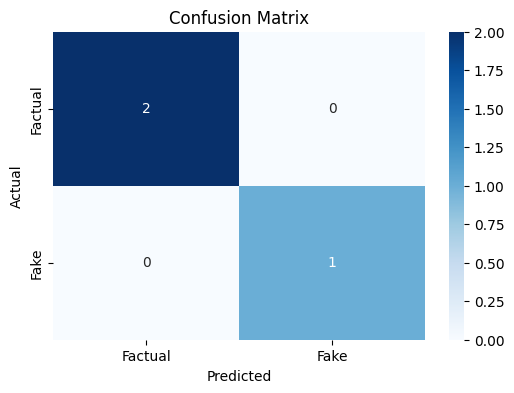

In [2]:
from sklearn.metrics import confusion_matrix

# Step 7: Final Evaluation
test_enc = tokenizer(X_test, truncation=True, padding=True, max_length=256)
test_dataset = NewsDataset(test_enc, y_test)
test_loader = DataLoader(test_dataset, batch_size=8)

model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_test, all_preds))
print("\nClassification Report:\n", classification_report(y_test, all_preds, target_names=['Factual News', 'Fake News']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Factual', 'Fake'], yticklabels=['Factual', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [3]:
def predict_news(text):
    # Prepare the input
    inputs = tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)

    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    return "Fake News" if prediction == 1 else "Factual News"

# Test examples
headlines = [
    "Scientists discover water on a new exoplanet in the habitable zone.",
    "Breaking: Local man finds secret portal to another dimension in his basement.",
    "Government announces new tax reforms to take effect next fiscal year."
]

for text in headlines:
    result = predict_news(text)
    print(f"Headline: {text}\nResult: {result}\n{'-'*30}")

Headline: Scientists discover water on a new exoplanet in the habitable zone.
Result: Factual News
------------------------------
Headline: Breaking: Local man finds secret portal to another dimension in his basement.
Result: Factual News
------------------------------
Headline: Government announces new tax reforms to take effect next fiscal year.
Result: Factual News
------------------------------


In [4]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# Re-initialize basic settings
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
MODEL_NAME = 'distilbert-base-uncased'

# Initialize tokenizer and model
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

print(f'Model and tokenizer re-initialized on {device}.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and tokenizer re-initialized on cuda.


In [5]:
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# Ensure model and tokenizer are defined in the current session
MODEL_NAME = 'distilbert-base-uncased'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

# Save trained model and tokenizer
model.save_pretrained("./fake_news_model")
tokenizer.save_pretrained("./fake_news_model")

print("Model and tokenizer saved successfully to ./fake_news_model")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully to ./fake_news_model


In [6]:
import os

print(os.listdir("./fake_news_model"))

['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']


In [7]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

saved_tokenizer = DistilBertTokenizerFast.from_pretrained(
    "./fake_news_model"
)

saved_model = DistilBertForSequenceClassification.from_pretrained(
    "./fake_news_model"
)

print("Saved model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Saved model loaded successfully!


In [8]:
import torch

def predict_news(title, text):

    input_text = title + " " + text

    inputs = saved_tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():

        outputs = saved_model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[0][predicted_class].item() * 100

    if predicted_class == 0:
        prediction = "Fake News"
    else:
        prediction = "Factual News"

    return prediction, confidence

In [9]:
title = "Example news headline"

text = """
This is an example news article.
The article contains some information
that the model will classify.
"""

prediction, confidence = predict_news(
    title,
    text
)

print("Prediction:", prediction)
print("Confidence:", round(confidence, 2), "%")

Prediction: Fake News
Confidence: 50.37 %


In [10]:
def predict_news(title, text):

    input_text = title + " " + text

    # The .to(device) ensures tensors match the model's location (CPU or GPU)
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0][predicted_class].item() * 100
    )

    return predicted_class, confidence

In [11]:
# Ensure model is on the correct device before calling
model.to(device)

prediction, confidence = predict_news(
    "Example news headline",
    "This is an example news article."
)

print("Class:", prediction)
print("Confidence:", round(confidence, 2), "%")

Class: 0
Confidence: 51.22 %


In [12]:
!pip install flask flask-cors pyngrok

In [13]:
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)


@app.route("/")
def home():

    return jsonify({
        "message": "Fake News Detection API is running"
    })


@app.route("/predict", methods=["POST"])
def predict():

    data = request.get_json()

    title = data.get("title", "")
    text = data.get("text", "")

    if not title and not text:

        return jsonify({
            "error": "Please enter news headline or article"
        }), 400


    predicted_class, confidence = predict_news(
        title,
        text
    )


    # IMPORTANT:
    # Change this only if your original label mapping
    # is different.

    if predicted_class == 0:
        prediction = "Fake News"
    else:
        prediction = "Factual News"


    return jsonify({

        "prediction": prediction,

        "confidence": round(confidence, 2)

    })

### Step 10: Set up the Public URL
Paste your ngrok token below to create a public link for your API.

In [16]:
import os

print("Checking model folder...")
print(os.path.exists("/content/fake_news_model"))

print("\nFiles inside model folder:")
print(os.listdir("/content/fake_news_model"))

Checking model folder...
True

Files inside model folder:
['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']


In [17]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
import torch

MODEL_PATH = "/content/fake_news_model"

tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_PATH
)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.eval()

print("✅ Tokenizer loaded successfully")
print("✅ Model loaded successfully")
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Tokenizer loaded successfully
✅ Model loaded successfully
Number of labels: 2


In [18]:
def predict_news(title, text):

    input_text = title + " " + text

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    predicted_class = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = (
        probabilities[0][predicted_class].item() * 100
    )

    return predicted_class, confidence

In [19]:
title = "Government announces new economic policy"

text = """
The government announced a new economic policy
to support economic development and employment.
"""

predicted_class, confidence = predict_news(
    title,
    text
)

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Predicted class: 1
Confidence: 50.34 %


In [33]:
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)

CORS(
    app,
    resources={
        r"/*": {
            "origins": "*"
        }
    },
    allow_headers=[
        "Content-Type",
        "ngrok-skip-browser-warning"
    ],
    methods=[
        "GET",
        "POST",
        "OPTIONS"
    ]
)

In [21]:
print("Flask API created successfully!")
print(app.url_map)

Flask API created successfully!
Map([<Rule '/static/<filename>' (GET, OPTIONS, HEAD) -> static>,
 <Rule '/' (GET, OPTIONS, HEAD) -> home>,
 <Rule '/predict' (POST, OPTIONS) -> predict>])


In [34]:
import threading

def run_flask():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )

flask_thread = threading.Thread(
    target=run_flask
)

flask_thread.start()

print("Flask server started")

 * Serving Flask app '__main__'
Flask server started
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [35]:
import requests

url = "https://cosigner-stunned-sputter.ngrok-free.dev/predict"

data = {
    "title": "Government announces new economic policy",
    "text": "The government announced a new economic policy to support economic development."
}

response = requests.post(
    url,
    json=data
)

print("Status:", response.status_code)
print("Response:", response.json())

INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 11:12:21] "POST /predict HTTP/1.1" 200 -


Status: 200
Response: {'confidence': 50.55, 'prediction': 'Fake News'}


In [26]:
!pip install pyngrok

In [28]:
from pyngrok import ngrok

public_url = ngrok.connect(5000)

print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://cosigner-stunned-sputter.ngrok-free.dev" -> "http://localhost:5000"


In [32]:
import requests

public_url = "https://cosigner-stunned-sputter.ngrok-free.dev"

response = requests.get(public_url)

print("Status:", response.status_code)
print("Response:")
print(response.text)

INFO:werkzeug:127.0.0.1 - - [12/Aug/2026 11:09:18] "GET / HTTP/1.1" 200 -


Status: 200
Response:
{"message":"Fake News Detection API is running","status":"success"}

